In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

# Phase 4 — Text representations and cosine similarity

Retrieval: every Abt (Amazon) record with a gold match ranks all Buy (Google) records by cosine similarity. Computed by `python -m src.embed`.

In [2]:
r = pd.read_csv(ROOT/'reports'/'phase4_retrieval.csv')
order = ['tfidf_word', 'tfidf_char', 'fasttext', 'minilm', 'bge']
main = r[r['input']=='text'].pivot(index='representation', columns='dataset', values=['recall@1','recall@5','mrr']).reindex(order)
main

recall@1               recall@5                   mrr              
dataset         abt_buy amazon_google  abt_buy amazon_google abt_buy amazon_google
representation                                                                    
tfidf_word        0.831         0.752    0.966         0.954   0.891         0.844
tfidf_char        0.786         0.699    0.943         0.948   0.856         0.810
fasttext          0.625         0.539    0.857         0.772   0.730         0.641
minilm            0.746         0.647    0.932         0.904   0.828         0.762
bge               0.803         0.686    0.955         0.927   0.872         0.791

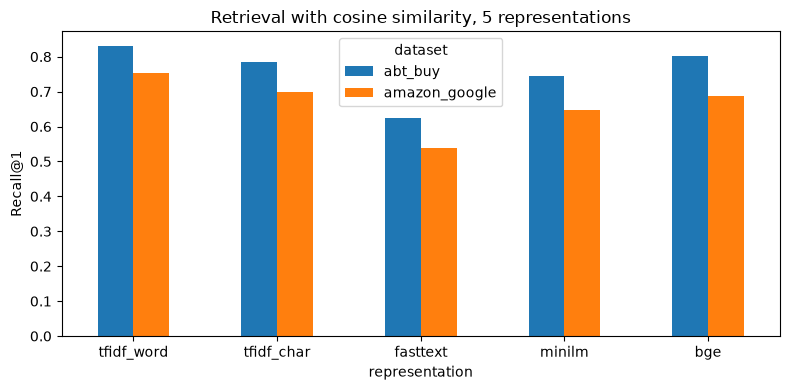

In [3]:
ax = main['recall@1'].plot.bar(figsize=(8,4)); ax.set_ylabel('Recall@1'); ax.set_title('Retrieval with cosine similarity, 5 representations')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(FIG/'phase4_recall1.png', dpi=120)

## Effect of Phase 2 normalization (raw vs normalized input)

In [4]:
r.pivot_table(index='representation', columns=['dataset','input'], values='recall@1').reindex(order)

dataset        abt_buy        amazon_google       
input              raw   text           raw   text
representation                                    
tfidf_word       0.645  0.831         0.750  0.752
tfidf_char       0.829  0.786         0.721  0.699
fasttext         0.393  0.625         0.552  0.539
minilm           0.722  0.746         0.649  0.647
bge              0.763  0.803         0.694  0.686

## Where representations disagree: Abt-Buy queries that word TF-IDF gets right and MiniLM gets wrong (and vice versa)

In [5]:
from src import embed as E
import numpy as np
left, right, gold = E.load_benchmark('abt_buy')
q = left[left['id'].isin(gold)].reset_index(drop=True)
top1 = {}
for kind in ['tfidf_word', 'minilm']:
    enc = E.Encoder(kind).fit(left['text'].tolist() + right['text'].tolist())
    idx, _ = E.cosine_topk(enc.encode(q['text'].tolist()), enc.encode(right['text'].tolist()), 1)
    top1[kind] = right['raw'].values[idx[:, 0]]
ok = {k: np.array([right.set_index('raw').loc[v, 'id'] if False else None for v in []]) for k in top1}
rid = dict(zip(right['raw'], right['id']))
hit = {k: np.array([rid[v] in gold[i] for v, i in zip(top1[k], q['id'])]) for k in top1}
d = pd.DataFrame({'query': q['raw'], 'tfidf_word top-1': top1['tfidf_word'], 'minilm top-1': top1['minilm'],
                  'tfidf ok': hit['tfidf_word'], 'minilm ok': hit['minilm']})
pd.concat([d[d['tfidf ok'] & ~d['minilm ok']].head(5), d[~d['tfidf ok'] & d['minilm ok']].head(5)])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,query,tfidf_word top-1,minilm top-1,tfidf ok,minilm ok
4,Bose 27028 161 Bookshelf Pair Speakers In White - 161WH,Boss 161 Speaker,Bose Acoustimass 5 Series III Speaker System - 21725,True,False
10,Panasonic Integrated Telephone System - KXTS108W,Panasonic KX-TS108W Corded Phone,Panasonic KX-TS600W Basic Telephone,True,False
11,Panasonic 2-Line Integrated Telephone System - KXTS208W,Panasonic KX-TS208W Corded Phone,Panasonic KX-TSC14W 2-Line Telephone,True,False
13,Sony 400 Disc MegaStorage CD Changer - CDPCX455,Sony CDP-CX455 CD Player/Changer - CDPCX455,Sony CDP-CX355 300 Disc MegaStorage CD Changer,True,False
39,GE GSD4000NWW White Built-In Dishwasher - GSD4000WH,GE GSD4000NWW Dishwasher with 5 Wash Cycles STD TUB ESTAR ( White) - gsd4000nww,GE GSD2400NWW Dishwasher with 5 Wash Cycles - gsd2400nww,True,False
34,Garmin Deluxe Carrying Case - Black Finish - 0101023101,Sony LCS Soft Carrying Case - LCSCST,Garmin Canvas Deluxe Carry Case - 010-10231-01,False,True
60,Sanus 13' - 30' VisionMount Flat Panel TV Silver Wall Mount - VMFS,Sanus VisionMount Flat Panel TV Wall Mount - VMPL3B,Sanus Flat Panel TV Wall Mount - VMF,False,True
63,Sony HD DVC Tape - DVM63HD,Sony XT-100HD HD Radio Tuner,Sony High Definition Mini DV Cassette - DSL-190-B,False,True
81,OmniMount G-303 Gray Stellar Series Audio Tower - G303GR,OmniMount Stellar G303 Series 3 Shelf Component Stand - Black - G303 DARK,OmniMount 3-Shelf Large-Component Tower - STELLARG303G,False,True
129,Whirlpool Duet Sport Front Loading White Washer - White Finish - WFW8300SWH,Whirlpool Duet Sport 27'' Electric Dryer - WED8300SWH 6.7 Cubic Foot Capacity,Whirlpool WFW8300SW 27' Front-Load Washer w/3.4 Cu. Ft. Capacity (White),False,True
